# Estimating Agrarian Land Efficiency

## Problem Statement

The task is to evaluate the efficiency of agricultural fields. Each field
is described by a set of attributes covering its dimensions, cultivated area, irrigation
infrastructure, water resources, soil fertility, and tax assessment values. Based on these
attributes, the objective is to classify each field into one of three performance categories:
**low**, **medium**, or **high**.

## Dataset

The training set consists of 112,569 samples, each identified by a unique `UID` and labeled with
a `Target` value (`low`, `medium`, or `high`). The test set consists of 15,921 samples with the
same feature columns but without the `Target` label; predictions generated for this set
constitute the final submission.

## Methodology

This notebook performs
exploratory data analysis, missing-value treatment, feature engineering, categorical encoding,
correlation-based feature pruning, feature selection, and classification using a Balanced Random
Forest to account for class imbalance in the target variable.

## Library Imports

The following cell imports the libraries required for data processing, visualization, and model
development.

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import Lasso, LogisticRegression

sns.set(rc={'figure.figsize':(11.7,8.27)})
%matplotlib inline

## Data Loading

The training dataset (`train.csv`), which includes the target labels, and the test dataset
(`test.csv`), for which predictions are to be generated, are loaded below.

In [2]:
TRAIN_FILE = '../data/train.csv'
TEST_FILE = '../data/test.csv'
PREDICTIONS_FILE = '../data/predictions.csv'

df = pd.read_csv(TRAIN_FILE)
train_df = df.copy()
X_test = pd.read_csv(TEST_FILE)

print("train_df:", train_df.shape)
print("X_test  :", X_test.shape)
train_df.head()

train_df: (112569, 58)
X_test  : (15921, 57)


,UID,AgriculturalPostalZone,AgricultureZoningCode,CropFieldConfiguration,CropSpeciesVariety,CultivatedAndWildArea,CultivatedAreaSqft1,DistrictId,FarmClassification,FarmEquipmentArea,...,TotalTaxAssessed,TotalValue,TownId,TypeOfIrrigationSystem,UndergroundStorageSqft,ValuationYear,WaterAccessPoints,WaterAccessPointsCalc,WaterReservoirCount,Target
0,12998,291674,0.0,NaN,3.0,NaN,1136.0,1.0,NaN,NaN,...,8636.716,456255.6,118.0,NaN,NaN,2018.0,2.0,2.0,NaN,high
1,20860,164397,28.0,NaN,4.0,NaN,2083.0,1.0,NaN,NaN,...,18464.292,996887.6,24.0,1.0,NaN,2018.0,3.0,3.0,1.0,medium
2,75725,616532,0.0,NaN,2.0,NaN,922.0,1.0,NaN,NaN,...,15594.568,1043780.0,9.0,1.0,NaN,2018.0,1.0,1.0,NaN,medium
3,106521,942111,43.0,NaN,7.0,NaN,NaN,1.0,NaN,NaN,...,8494.618,435734.8,114.0,NaN,NaN,2020.0,3.0,3.0,NaN,low
4,99467,475557,38.0,NaN,3.0,NaN,2225.0,3.0,NaN,0.0,...,13517.284,885400.0,6.0,NaN,NaN,2020.0,4.0,4.0,NaN,medium


## Exploratory Data Analysis

### Dataset Overview

The shape, data types, and summary statistics of the training data are examined first. With the
exception of the `Target` column, all features are numeric, as categorical variables were
pre-encoded in the provided dataset.

In [3]:
print("Shape:", train_df.shape)
print("\nDtypes:")
print(train_df.dtypes)

Shape: (112569, 58)

Dtypes:
UID                               int64
AgriculturalPostalZone            int64
AgricultureZoningCode           float64
CropFieldConfiguration          float64
CropSpeciesVariety              float64
CultivatedAndWildArea           float64
CultivatedAreaSqft1             float64
DistrictId                      float64
FarmClassification              float64
FarmEquipmentArea               float64
FarmShedAreaSqft                float64
FarmVehicleCount                float64
FarmingCommunityId              float64
FarmingUnitCount                float64
FieldConstructionType           float64
FieldEstablishedYear            float64
FieldShadeCover                 float64
FieldSizeSqft                   float64
FieldZoneLevel                  float64
HarvestProcessingType           float64
HarvestStorageSqft              float64
HasGreenHouse                   float64
HasPestControl                  float64
LandUsageType                   float64
Latitude   

In [4]:
train_df.describe()

,UID,AgriculturalPostalZone,AgricultureZoningCode,CropFieldConfiguration,CropSpeciesVariety,CultivatedAndWildArea,CultivatedAreaSqft1,DistrictId,FarmClassification,FarmEquipmentArea,...,TotalReservoirSize,TotalTaxAssessed,TotalValue,TownId,TypeOfIrrigationSystem,UndergroundStorageSqft,ValuationYear,WaterAccessPoints,WaterAccessPointsCalc,WaterReservoirCount
count,112569.000000,112569.000000,112435.000000,295.000000,112549.000000,542.000000,107048.000000,112549.000000,17.000000,37344.000000,...,1237.000000,1.125410e+05,1.122390e+05,110312.000000,36436.000000,57.000000,112549.000000,112549.000000,111376.000000,23164.0
mean,80381.350478,549628.932486,16.677752,1.362712,3.047339,2188.269373,1756.980448,1.430293,1.058824,348.505597,...,516.610348,1.321101e+04,7.834862e+05,40.713794,1.144088,722.614035,2018.921590,2.295489,2.319131,1.0
std,46358.650859,260215.386949,14.162778,1.020520,1.143737,1288.498812,919.479487,0.637208,0.242536,261.962169,...,153.176084,1.585350e+04,1.094734e+06,40.871474,0.520673,664.110139,0.996926,0.995723,0.972990,0.0
min,1.000000,100114.000000,0.000000,1.000000,0.000000,257.000000,2.000000,1.000000,1.000000,0.000000,...,28.000000,4.382400e+01,5.753200e+03,1.000000,1.000000,38.000000,2018.000000,0.000000,1.000000,1.0
25%,40277.000000,324628.000000,0.000000,1.000000,2.000000,1024.750000,1176.000000,1.000000,1.000000,0.000000,...,420.000000,6.230048e+03,2.915380e+05,4.000000,1.000000,280.000000,2018.000000,2.000000,2.000000,1.0
50%,80588.000000,547794.000000,20.000000,1.000000,3.000000,1882.500000,1525.000000,1.000000,1.000000,436.000000,...,499.000000,9.968442e+03,5.662584e+05,29.000000,1.000000,600.000000,2018.000000,2.000000,2.000000,1.0
75%,120456.000000,776138.000000,26.000000,1.000000,4.000000,3253.500000,2073.000000,2.000000,1.000000,489.000000,...,600.000000,1.528993e+04,9.377373e+05,63.000000,1.000000,814.000000,2020.000000,3.000000,3.000000,1.0
max,160814.000000,999982.000000,51.000000,6.000000,16.000000,6337.000000,21929.000000,3.000000,2.000000,4048.000000,...,1749.000000,1.290606e+06,1.077821e+08,178.000000,6.000000,3560.000000,2020.000000,20.000000,20.000000,1.0


### Duplicate Records

The dataset is checked for duplicate rows, which, if present, could bias model training.

In [5]:
print("Duplicated rows:", train_df.duplicated().sum())

Duplicated rows: 0


### Quasi-Constant Features

Columns in which a single value accounts for more than 99% of observations are identified, as
such features contribute negligible discriminative information.

In [6]:
# Columns where a single value accounts for more than 99% of rows
drop1 = list(filter(lambda keys: train_df[keys].value_counts().max() > 0.99 * train_df.shape[0], train_df.keys()))
print("Quasi-constant columns (>99% single value):", drop1)

Quasi-constant columns (>99% single value): []


### Correlation Analysis

A correlation heatmap is generated over the numeric features to identify relationships between
variables. This analysis is used later in the pipeline to remove redundant, highly correlated
features.

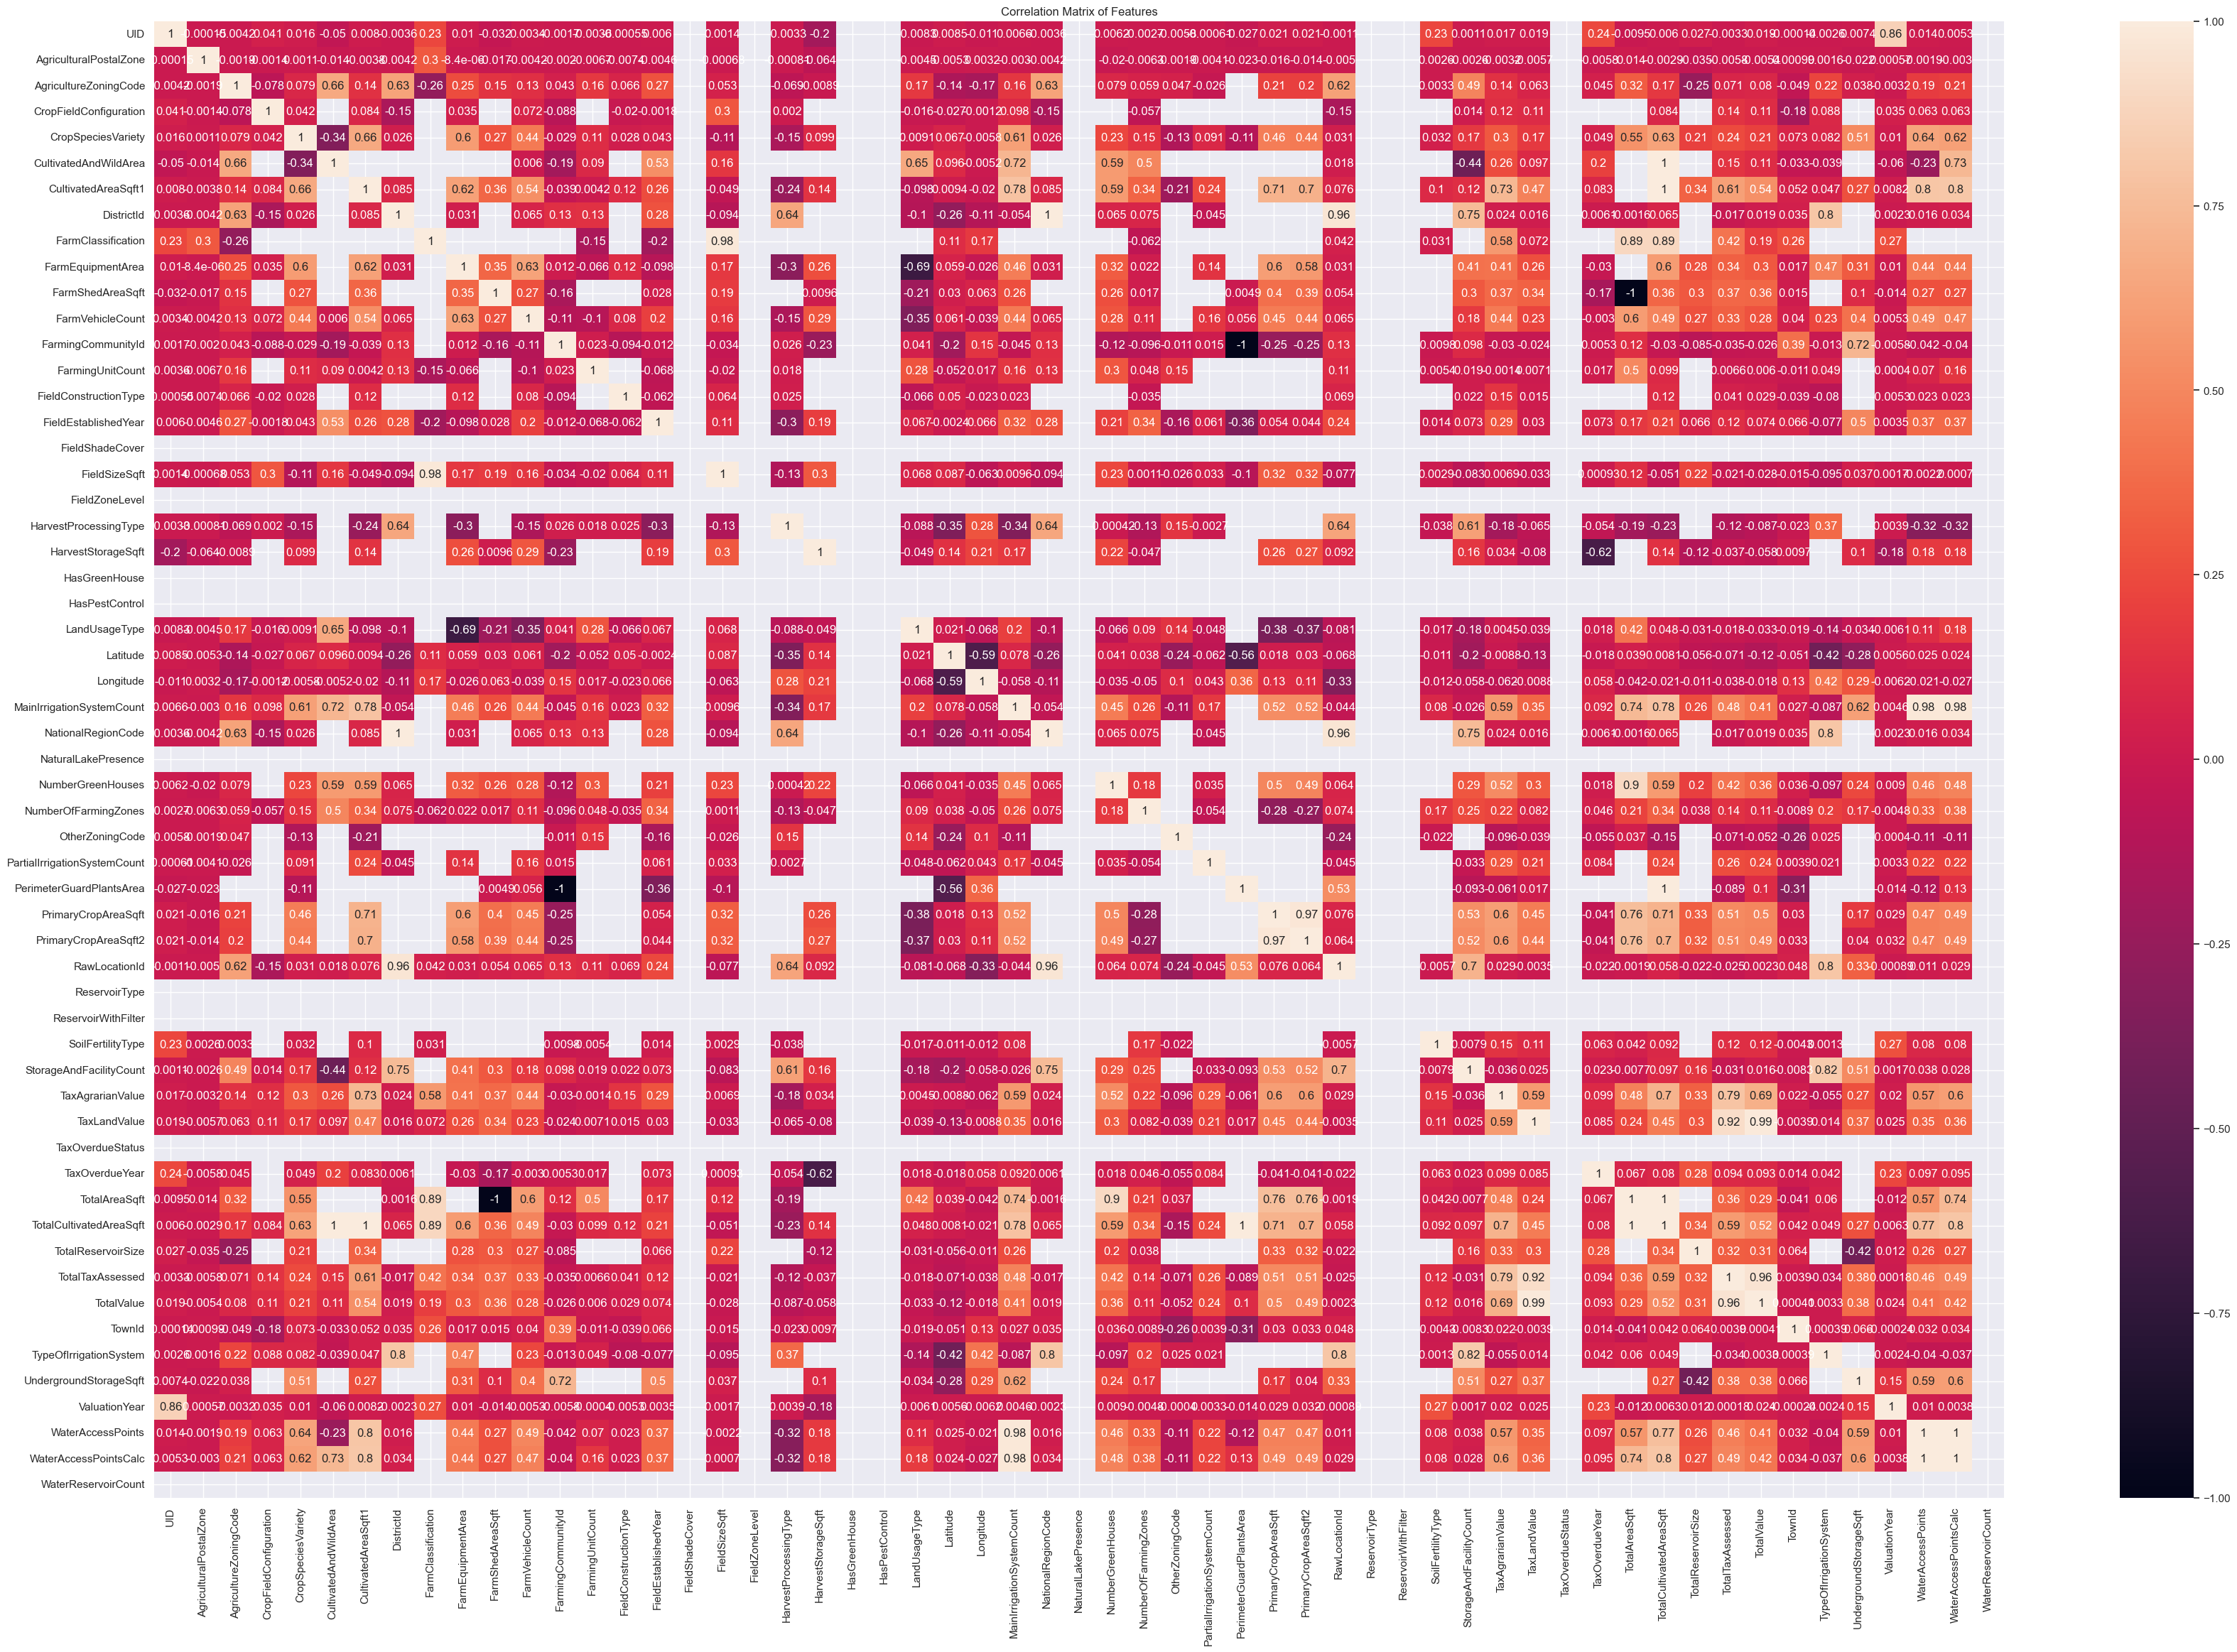

In [7]:
correlation_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(42, 27))
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix of Features')
plt.show()

### Missing Value Analysis

The proportion of missing values is computed for each feature. This informs the subsequent
decision to impute or drop specific columns.

In [8]:
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_percentage_sorted = missing_percentage.sort_values(ascending=False)
print(missing_percentage_sorted)

FarmClassification              99.984898
PerimeterGuardPlantsArea        99.960913
UndergroundStorageSqft          99.949364
FieldZoneLevel                  99.949364
HarvestStorageSqft              99.900505
HasGreenHouse                   99.765477
CropFieldConfiguration          99.737939
FieldConstructionType           99.706846
CultivatedAndWildArea           99.518518
FieldShadeCover                 99.228917
ReservoirType                   99.029928
TotalReservoirSize              98.901118
ReservoirWithFilter             98.634615
HasPestControl                  97.664544
TaxOverdueYear                  97.287886
TaxOverdueStatus                97.287886
FarmShedAreaSqft                96.978742
TotalAreaSqft                   96.131262
PrimaryCropAreaSqft             92.277625
PrimaryCropAreaSqft2            92.277625
NumberGreenHouses               89.253702
PartialIrrigationSystemCount    86.631311
NaturalLakePresence             80.799332
WaterReservoirCount             79

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112569 entries, 0 to 112568
Data columns (total 58 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   UID                           112569 non-null  int64  
 1   AgriculturalPostalZone        112569 non-null  int64  
 2   AgricultureZoningCode         112435 non-null  float64
 3   CropFieldConfiguration        295 non-null     float64
 4   CropSpeciesVariety            112549 non-null  float64
 5   CultivatedAndWildArea         542 non-null     float64
 6   CultivatedAreaSqft1           107048 non-null  float64
 7   DistrictId                    112549 non-null  float64
 8   FarmClassification            17 non-null      float64
 9   FarmEquipmentArea             37344 non-null   float64
 10  FarmShedAreaSqft              3401 non-null    float64
 11  FarmVehicleCount              37344 non-null   float64
 12  FarmingCommunityId            44684 non-null

### Target Distribution

The distribution of the target classes is examined. The classes are found to be imbalanced, with
the `medium` category considerably more frequent than `low` or `high`. This imbalance motivates
the use of a Balanced Random Forest classifier at the modelling stage.

In [10]:
train_df['Target'].value_counts()

Target
medium    67541
high      22514
low       22514
Name: count, dtype: int64

## Data Preprocessing Pipeline

The following functions implement the preprocessing, feature engineering, and modelling
pipeline.

### Feature-Target Separation

The target variable is separated from the feature set, and the categorical labels (`low`,
`medium`, `high`) are encoded as integers (0, 1, 2) for compatibility with classification
algorithms.

In [11]:
def data_preprocessing(train_df, X_test):
    # Columns where a single value accounts for more than 99% of rows (quasi-constant features).
    # They are incapable of contributing to the performance of the model, so they will be dropped
    # later. As shown in the EDA above, there are none in this dataset.
    drop1 = list(filter(lambda keys: train_df[keys].value_counts().max() > 0.99 * train_df.shape[0], train_df.keys()))

    # Train/target splitting and label encoding.
    # As shown in the EDA above, the dataset has 0 duplicated rows, so no de-duplication is needed.
    X_train = train_df.drop(['Target'], axis=1)
    target_mapping = {'low': 0, 'medium': 1, 'high': 2}
    y_train = train_df['Target'].map(target_mapping)

    return X_train, y_train

### Missing Value Treatment

Rows with a low proportion of missing values (below 2%) are removed for the corresponding
columns, and columns with more than 90% missing values are dropped entirely. Remaining missing
values in selected columns (`HarvestProcessingType`, `CultivatedAreaSqft1`, `FieldSizeSqft`,
`SoilFertilityType`) are imputed using group-wise mode or mean statistics derived from related
columns, with an overall mode or mean applied as a fallback. All imputation statistics are
computed from the training set and applied consistently to the test set.

In [12]:
def EDA(X_train, y_train, X_test):
    # Removing rows for those columns that have NULL values less than 2 percent
    threshold = 0.02 * X_train.shape[0]
    for column in X_train.columns:
        nan_count = X_train[column].isna().sum()
        if nan_count < threshold:
            rows_to_keep = ~X_train[column].isna()
            X_train = X_train[rows_to_keep]
            y_train = y_train[rows_to_keep]

    # Removing columns that have more than 90% null values.
    missing_percentage = (X_train.isnull().sum() / len(X_train)) * 100
    columns_to_drop = missing_percentage[missing_percentage > 90].index
    print("Dropped column = ", list(columns_to_drop))

    dropped_columns = list(columns_to_drop.copy())

    # Imputing values using correlated columns that have comparatively fewer NULL values

    # Impute missing 'HarvestProcessingType' values in X_train
    X_train['HarvestProcessingType'] = X_train['HarvestProcessingType'].fillna(
        X_train.groupby('RawLocationId')['HarvestProcessingType'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
    X_train['HarvestProcessingType'] = X_train['HarvestProcessingType'].fillna(
        X_train.groupby('NationalRegionCode')['HarvestProcessingType'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
    X_train['HarvestProcessingType'] = X_train['HarvestProcessingType'].fillna(
        X_train.groupby('DistrictId')['HarvestProcessingType'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )

    # Fallback to overall mode if still missing
    overall_mode_harvest = X_train['HarvestProcessingType'].mode().iloc[0]
    X_train['HarvestProcessingType'] = X_train['HarvestProcessingType'].fillna(overall_mode_harvest)

    # Now, apply the same filling strategy to X_test based on X_train values
    X_test['HarvestProcessingType'] = X_test['HarvestProcessingType'].fillna(
        X_test['RawLocationId'].map(X_train.groupby('RawLocationId')['HarvestProcessingType'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ))
    )
    X_test['HarvestProcessingType'] = X_test['HarvestProcessingType'].fillna(
        X_test['NationalRegionCode'].map(X_train.groupby('NationalRegionCode')['HarvestProcessingType'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ))
    )
    X_test['HarvestProcessingType'] = X_test['HarvestProcessingType'].fillna(
        X_test['DistrictId'].map(X_train.groupby('DistrictId')['HarvestProcessingType'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        ))
    )

    # Fallback to overall mode from X_train if still missing
    X_test['HarvestProcessingType'] = X_test['HarvestProcessingType'].fillna(overall_mode_harvest)

    # Impute missing 'CultivatedAreaSqft1' values in X_train
    X_train['CultivatedAreaSqft1'] = X_train['CultivatedAreaSqft1'].fillna(
        X_train.groupby('TotalCultivatedAreaSqft')['CultivatedAreaSqft1'].transform('mean')
    )
    X_train['CultivatedAreaSqft1'] = X_train['CultivatedAreaSqft1'].fillna(
        X_train.groupby('MainIrrigationSystemCount')['CultivatedAreaSqft1'].transform('mean')
    )
    X_train['CultivatedAreaSqft1'] = X_train['CultivatedAreaSqft1'].fillna(
        X_train.groupby('TaxAgrarianValue')['CultivatedAreaSqft1'].transform('mean')
    )

    # Fallback to the whole column mean if still missing
    X_train['CultivatedAreaSqft1'] = X_train['CultivatedAreaSqft1'].fillna(X_train['CultivatedAreaSqft1'].mean())

    # Now, apply the same filling strategy to X_test based on X_train values
    X_test['CultivatedAreaSqft1'] = X_test['CultivatedAreaSqft1'].fillna(
        X_test['TotalCultivatedAreaSqft'].map(X_train.groupby('TotalCultivatedAreaSqft')['CultivatedAreaSqft1'].transform('mean'))
    )
    X_test['CultivatedAreaSqft1'] = X_test['CultivatedAreaSqft1'].fillna(
        X_test['MainIrrigationSystemCount'].map(X_train.groupby('MainIrrigationSystemCount')['CultivatedAreaSqft1'].transform('mean'))
    )
    X_test['CultivatedAreaSqft1'] = X_test['CultivatedAreaSqft1'].fillna(
        X_test['TaxAgrarianValue'].map(X_train.groupby('TaxAgrarianValue')['CultivatedAreaSqft1'].transform('mean'))
    )

    # Fallback - Fill any remaining missing values in 'CultivatedAreaSqft1' with the whole column mean from X_train
    X_test['CultivatedAreaSqft1'] = X_test['CultivatedAreaSqft1'].fillna(X_train['CultivatedAreaSqft1'].mean())

    # Impute missing 'FieldSizeSqft' values in X_train
    X_train['FieldSizeSqft'] = X_train['FieldSizeSqft'].fillna(
        X_train.groupby('TownId')['FieldSizeSqft'].transform('mean')
    )

    # Fallback to the whole column mean if still missing
    X_train['FieldSizeSqft'] = X_train['FieldSizeSqft'].fillna(X_train['FieldSizeSqft'].mean())

    # Now, apply the same filling strategy to X_test based on X_train values
    X_test['FieldSizeSqft'] = X_test['FieldSizeSqft'].fillna(
        X_test['TownId'].map(X_train.groupby('TownId')['FieldSizeSqft'].transform('mean'))
    )

    # Fallback - Fill any remaining missing values in 'FieldSizeSqft' with the whole column mean from X_train
    X_test['FieldSizeSqft'] = X_test['FieldSizeSqft'].fillna(X_train['FieldSizeSqft'].mean())

    # Impute missing 'SoilFertilityType' values in X_train using the mode
    mode_soil_fertility = X_train['SoilFertilityType'].mode()[0]
    X_train['SoilFertilityType'] = X_train['SoilFertilityType'].fillna(mode_soil_fertility)

    # Now, apply the same imputation to X_test using the mode from X_train
    X_test['SoilFertilityType'] = X_test['SoilFertilityType'].fillna(mode_soil_fertility)

    return dropped_columns, X_train, y_train, X_test

### Feature Distribution Analysis

Histograms of the numeric features are plotted to examine their distributions and identify any
notable skewness or irregularities.

In [13]:
def histogramAnalysis(dropped_columns, X_train, y_train, X_test):
    numerical_columns = [
        'UndergroundStorageSqft', 'WaterAccessPoints', 'WaterAccessPointsCalc', 'CropSpeciesVariety',
        'PrimaryCropAreaSqft', 'TotalCultivatedAreaSqft', 'CultivatedAreaSqft1', 'PerimeterGuardPlantsArea', 'CultivatedAndWildArea', 'TotalAreaSqft', 'NationalRegionCode',
        'NumberGreenHouses', 'MainIrrigationSystemCount', 'FarmVehicleCount', 'FarmEquipmentArea',
        'Latitude', 'Longitude', 'FieldSizeSqft', 'WaterReservoirCount', 'TotalReservoirSize', 'RawLocationId',
        'TownId', 'DistrictId', 'FarmingCommunityId', 'AgriculturalPostalZone', 'StorageAndFacilityCount',
        'PartialIrrigationSystemCount', 'FarmingUnitCount', 'FarmShedAreaSqft', 'HarvestStorageSqft',
        'FieldEstablishedYear', 'NumberOfFarmingZones', 'TaxAgrarianValue', 'TaxLandValue',
        'TotalValue', 'TotalTaxAssessed', 'ValuationYear', 'TaxOverdueYear'
    ]
    numerical_columns = set(numerical_columns)  # Convert to set if it's not already

    # Filter the DataFrame as before
    X_train_filtered = X_train[list(numerical_columns.difference(dropped_columns))]
    # Set up the plot grid
    num_columns = 5  # Number of plots per row
    num_rows = (len(X_train_filtered.columns) + num_columns - 1) // num_columns

    # Create a larger figure with custom spacing
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 15))  # Adjust size as needed

    # Flatten axes for easy indexing (in case num_columns * num_rows > len(X_train_filtered.columns))
    axes = axes.flatten()

    # Plot each column's histogram with customizations
    for i, column in enumerate(X_train_filtered.columns):
        X_train_filtered[column].hist(
            ax=axes[i],
            grid=False,
            bins=20,
            color='skyblue',
            edgecolor='black',
            alpha=0.7
        )
        axes[i].set_title(column, fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

    # Remove any empty subplots (in case number of columns isn't a multiple of num_columns)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout for better spacing
    plt.tight_layout(pad=2.0)  # pad controls space between plots
    plt.show()

    return dropped_columns, X_train, y_train, X_test

## Feature Engineering

Additional features are derived from the existing attributes to capture domain-relevant
information, including farm age, tax burden, irrigation and water-resource density, and an
aggregate field utilization measure. These features are computed identically for the training
and test sets.

In [14]:
def enhance_features(data):
    print("\nEnhancing Features...")

    # Tax burden ratio and agrarian value ratio
    data['TaxBurden'] = data['TotalTaxAssessed'] / (data['TotalValue'] + 1)
    data['AgrarianValueProportion'] = data['TaxAgrarianValue'] / (data['TotalValue'] + 1)

    # Farm age based on field establishment year
    data['FarmAgeYears'] = data['ValuationYear'].max() - data['FieldEstablishedYear']

    # Irrigation count considering partial systems
    data['TotalIrrigationSystems'] = (data["MainIrrigationSystemCount"] +
                                      (data["PartialIrrigationSystemCount"].fillna(0) * 0.5))

    # Irrigation density per cultivated area
    data['IrrigationAreaDensity'] = data['TotalIrrigationSystems'] / data['TotalCultivatedAreaSqft']

    # Water resource availability by combining access points and reservoirs
    data['WaterResources'] = data['WaterAccessPoints'] + data['WaterReservoirCount'] + \
                             (data['NaturalLakePresence'] * 0.5) * (data['WaterAccessPoints'] + data['WaterReservoirCount'])

    # Water resource density per cultivated area
    data['WaterAreaDensity'] = data['WaterResources'] / data['TotalCultivatedAreaSqft']

    # Field efficiency considering various factors
    data['FieldUtilization'] = (data['SoilFertilityType'] + data['WaterResources'] +
                                data['FarmVehicleCount'] + data['TotalIrrigationSystems'] +
                                data['StorageAndFacilityCount']) / data['FieldSizeSqft']

    return data

## Categorical Encoding and Imputation

The remaining categorical variables (`LandUsageType`, `HarvestProcessingType`,
`TypeOfIrrigationSystem`, `SoilFertilityType`) are one-hot encoded. The test set's columns are
aligned with those of the training set, and any remaining missing values are imputed using
statistics derived exclusively from the training data.

In [15]:
def onehotencoding_and_imputing(dropped_columns, X_train, y_train, X_test):
    X_train = pd.get_dummies(X_train, columns=['LandUsageType'], prefix='LandUsageType')
    dropped_columns.append('LandUsageType')

    X_train = pd.get_dummies(X_train, columns=['HarvestProcessingType'], prefix='HarvestProcessingType')
    dropped_columns.append('HarvestProcessingType')

    X_train = pd.get_dummies(X_train, columns=['TypeOfIrrigationSystem'], prefix='TypeOfIrrigationSystem')
    dropped_columns.append('TypeOfIrrigationSystem')

    X_train = pd.get_dummies(X_train, columns=['SoilFertilityType'], prefix='SoilFertilityType')
    dropped_columns.append('SoilFertilityType')

    # Apply the same one-hot encoding to X_test
    X_test = pd.get_dummies(X_test, columns=['TypeOfIrrigationSystem'], prefix='TypeOfIrrigationSystem')
    X_test = pd.get_dummies(X_test, columns=['HarvestProcessingType'], prefix='HarvestProcessingType')
    X_test = pd.get_dummies(X_test, columns=['LandUsageType'], prefix='LandUsageType')
    X_test = pd.get_dummies(X_test, columns=['SoilFertilityType'], prefix='SoilFertilityType')

    # Align the columns of X_test with X_train by adding missing columns (with all zeros)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Identify columns with missing values in X_train and X_test
    columns_with_nulls_train = X_train.columns[X_train.isna().any()]
    columns_with_nulls_test = X_test.columns[X_test.isna().any()]

    # Perform mean imputation using only the means from X_train
    for col in columns_with_nulls_train:
        # Impute missing values in X_train with its mean
        mean_value = X_train[col].mean()
        X_train[col] = X_train[col].fillna(mean_value)

        # Impute missing values in X_test with the same mean from X_train
        if col in X_test.columns:
            X_test[col] = X_test[col].fillna(mean_value)

    # For any columns in X_test with missing values that aren't in X_train,
    # fill with a constant (e.g., 0 or another placeholder value)
    for col in columns_with_nulls_test:
        if col not in columns_with_nulls_train:
            X_test[col] = X_test[col].fillna(0)  # or choose another placeholder value

    dropped_columns.append('Latitude')
    dropped_columns.append('Longitude')
    dropped_columns.append('UID')

    return dropped_columns, X_train, y_train, X_test

### Removal of Highly Correlated Features

Pairs of features with a correlation coefficient above 0.9 are identified, and the feature with
the greater proportion of missing values within each pair is marked for removal.

In [16]:
def identify_highly_correlated_columns(dropped_columns, data, threshold=0.9):
    # Step 1: Compute the correlation matrix
    corr_matrix = data.corr().abs()

    # Step 2: Create an upper triangle matrix mask to ignore duplicate pairs
    upper_tri = corr_matrix.mask(np.tril(np.ones(corr_matrix.shape)).astype(bool))

    # Step 3: Identify pairs of columns with correlation above the threshold
    columns_to_drop = set()
    for col in upper_tri.columns:
        high_corr_cols = upper_tri.index[upper_tri[col] > threshold].tolist()
        for high_corr_col in high_corr_cols:
            # Choose the column with more null values to drop
            if data[col].isnull().sum() <= data[high_corr_col].isnull().sum():
                columns_to_drop.add(high_corr_col)
            else:
                columns_to_drop.add(col)

    # Update the dropped_columns list with identified columns to drop
    dropped_columns.extend(columns_to_drop)

    return dropped_columns

## Feature Selection

Feature importance is assessed using three complementary methods: Random Forest feature
importance, mutual information, and Lasso regression coefficients. The scores from each method
are aggregated, and the top 25 features are selected for model training.

In [17]:
def select_features(X_train, X_test, y_train, n_features=25):
    """
    Select features using multiple methods and voting.
    Returns selected train and test features.
    """
    feature_scores = {feature: 0 for feature in X_train.columns}

    # 1. Random Forest Importance
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    for feature, importance in zip(X_train.columns, rf.feature_importances_):
        feature_scores[feature] += importance

    # 2. Mutual Information
    mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
    mi_selector.fit(X_train, y_train)
    for feature, score in zip(X_train.columns, mi_selector.scores_):
        feature_scores[feature] += score / np.max(mi_selector.scores_)

    # 3. Lasso Feature Selection
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    lasso = Lasso(alpha=0.01, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    for feature, coef in zip(X_train.columns, np.abs(lasso.coef_)):
        feature_scores[feature] += coef / np.max(np.abs(lasso.coef_))

    # Select top features
    selected_features = pd.DataFrame({
        'Feature': feature_scores.keys(),
        'Score': feature_scores.values()
    }).nlargest(n_features, 'Score')['Feature'].tolist()

    return X_train[selected_features], X_test[selected_features]

## Model Training

A Balanced Random Forest Classifier is used to address the class imbalance present in the target
variable. Principal Component Analysis was evaluated during development but was not adopted in
the final pipeline; the corresponding code is retained below as a comment for reference.

In [18]:
def pca_and_model_training(X_train_selected, X_test_selected, y_train):
    # PCA was tried but left disabled in the original work (kept commented for parity):
    # pca = PCA(n_components=0.95)  # Keep 95% explained variance
    # X_train_pca = pca.fit_transform(X_train_selected)
    # X_test_pca = pca.transform(X_test_selected)

    # Define the Balanced Random Forest Classifier model
    model = BalancedRandomForestClassifier(
        n_estimators=100,
        sampling_strategy='all',  # Change default from 'auto' to 'all'
        replacement=True,         # Change default from False to True
        bootstrap=False,          # Change default from True to False
        random_state=42
    )

    # Fit the model on the training data
    model.fit(X_train_selected, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test_selected)

    return model, y_pred

## End-to-End Pipeline Function

The function below, `make_predictions`, consolidates the complete pipeline and corresponds
directly to the implementation in `balanced_random_forest_classifier.py`. It is retained here for
consistency between the notebook and the script. The pipeline is executed step by step in the
following section to allow inspection of intermediate outputs.

In [19]:
def make_predictions(test_fname, predictions_fname):
    # loading the train dataset
    df = pd.read_csv('../data/train.csv')
    train_df = df.copy()

    # loading the test dataset
    X_test = pd.read_csv(test_fname)

    X_train, y_train = data_preprocessing(train_df, X_test)

    dropped_columns, X_train, y_train, X_test = EDA(X_train, y_train, X_test)

    dropped_columns, X_train, y_train, X_test = histogramAnalysis(dropped_columns, X_train, y_train, X_test)

    X_train = enhance_features(X_train)
    X_test = enhance_features(X_test)

    dropped_columns, X_train, y_train, X_test = onehotencoding_and_imputing(dropped_columns, X_train, y_train, X_test)

    dropped_columns = identify_highly_correlated_columns(dropped_columns, X_train[list(X_train.columns.difference(dropped_columns))])

    # Prepare X_train_features and X_test_features by excluding the dropped columns
    X_train_features = X_train[list(X_train.columns.difference(dropped_columns))]
    X_test_features = X_test[list(X_train.columns.difference(dropped_columns))]

    X_train_selected, X_test_selected = select_features(X_train_features, X_test_features, y_train)

    _, y_pred = pca_and_model_training(X_train_selected, X_test_selected, y_train)

    target_mapping = {0: 'low', 1: 'medium', 2: 'high'}

    # Remap y_pred using the mapping
    y_pred_mapped = pd.Series(y_pred).map(target_mapping)

    result_df = pd.DataFrame({
        'UID': X_test['UID'],
        'Target': y_pred_mapped
    })

    # Write the submission data to a CSV file
    result_df.to_csv(predictions_fname, index=False)
    return result_df

## Pipeline Execution

The steps defined above are executed sequentially, replicating the logic of `make_predictions`,
to allow intermediate results to be inspected at each stage.

In [20]:
X_train, y_train = data_preprocessing(train_df, X_test)
X_train.shape, y_train.shape, X_test.shape

((112569, 57), (112569,), (15921, 57))

In [21]:
dropped_columns, X_train, y_train, X_test = EDA(X_train, y_train, X_test)
X_train.shape, y_train.shape, X_test.shape

Dropped column =  ['CropFieldConfiguration', 'CultivatedAndWildArea', 'FarmClassification', 'FarmShedAreaSqft', 'FieldConstructionType', 'FieldShadeCover', 'FieldZoneLevel', 'HarvestStorageSqft', 'HasGreenHouse', 'HasPestControl', 'PerimeterGuardPlantsArea', 'PrimaryCropAreaSqft', 'PrimaryCropAreaSqft2', 'ReservoirType', 'ReservoirWithFilter', 'TaxOverdueStatus', 'TaxOverdueYear', 'TotalAreaSqft', 'TotalReservoirSize', 'UndergroundStorageSqft']


((108985, 57), (108985,), (15921, 57))

The feature distributions are re-examined following the missing-value treatment described
above.

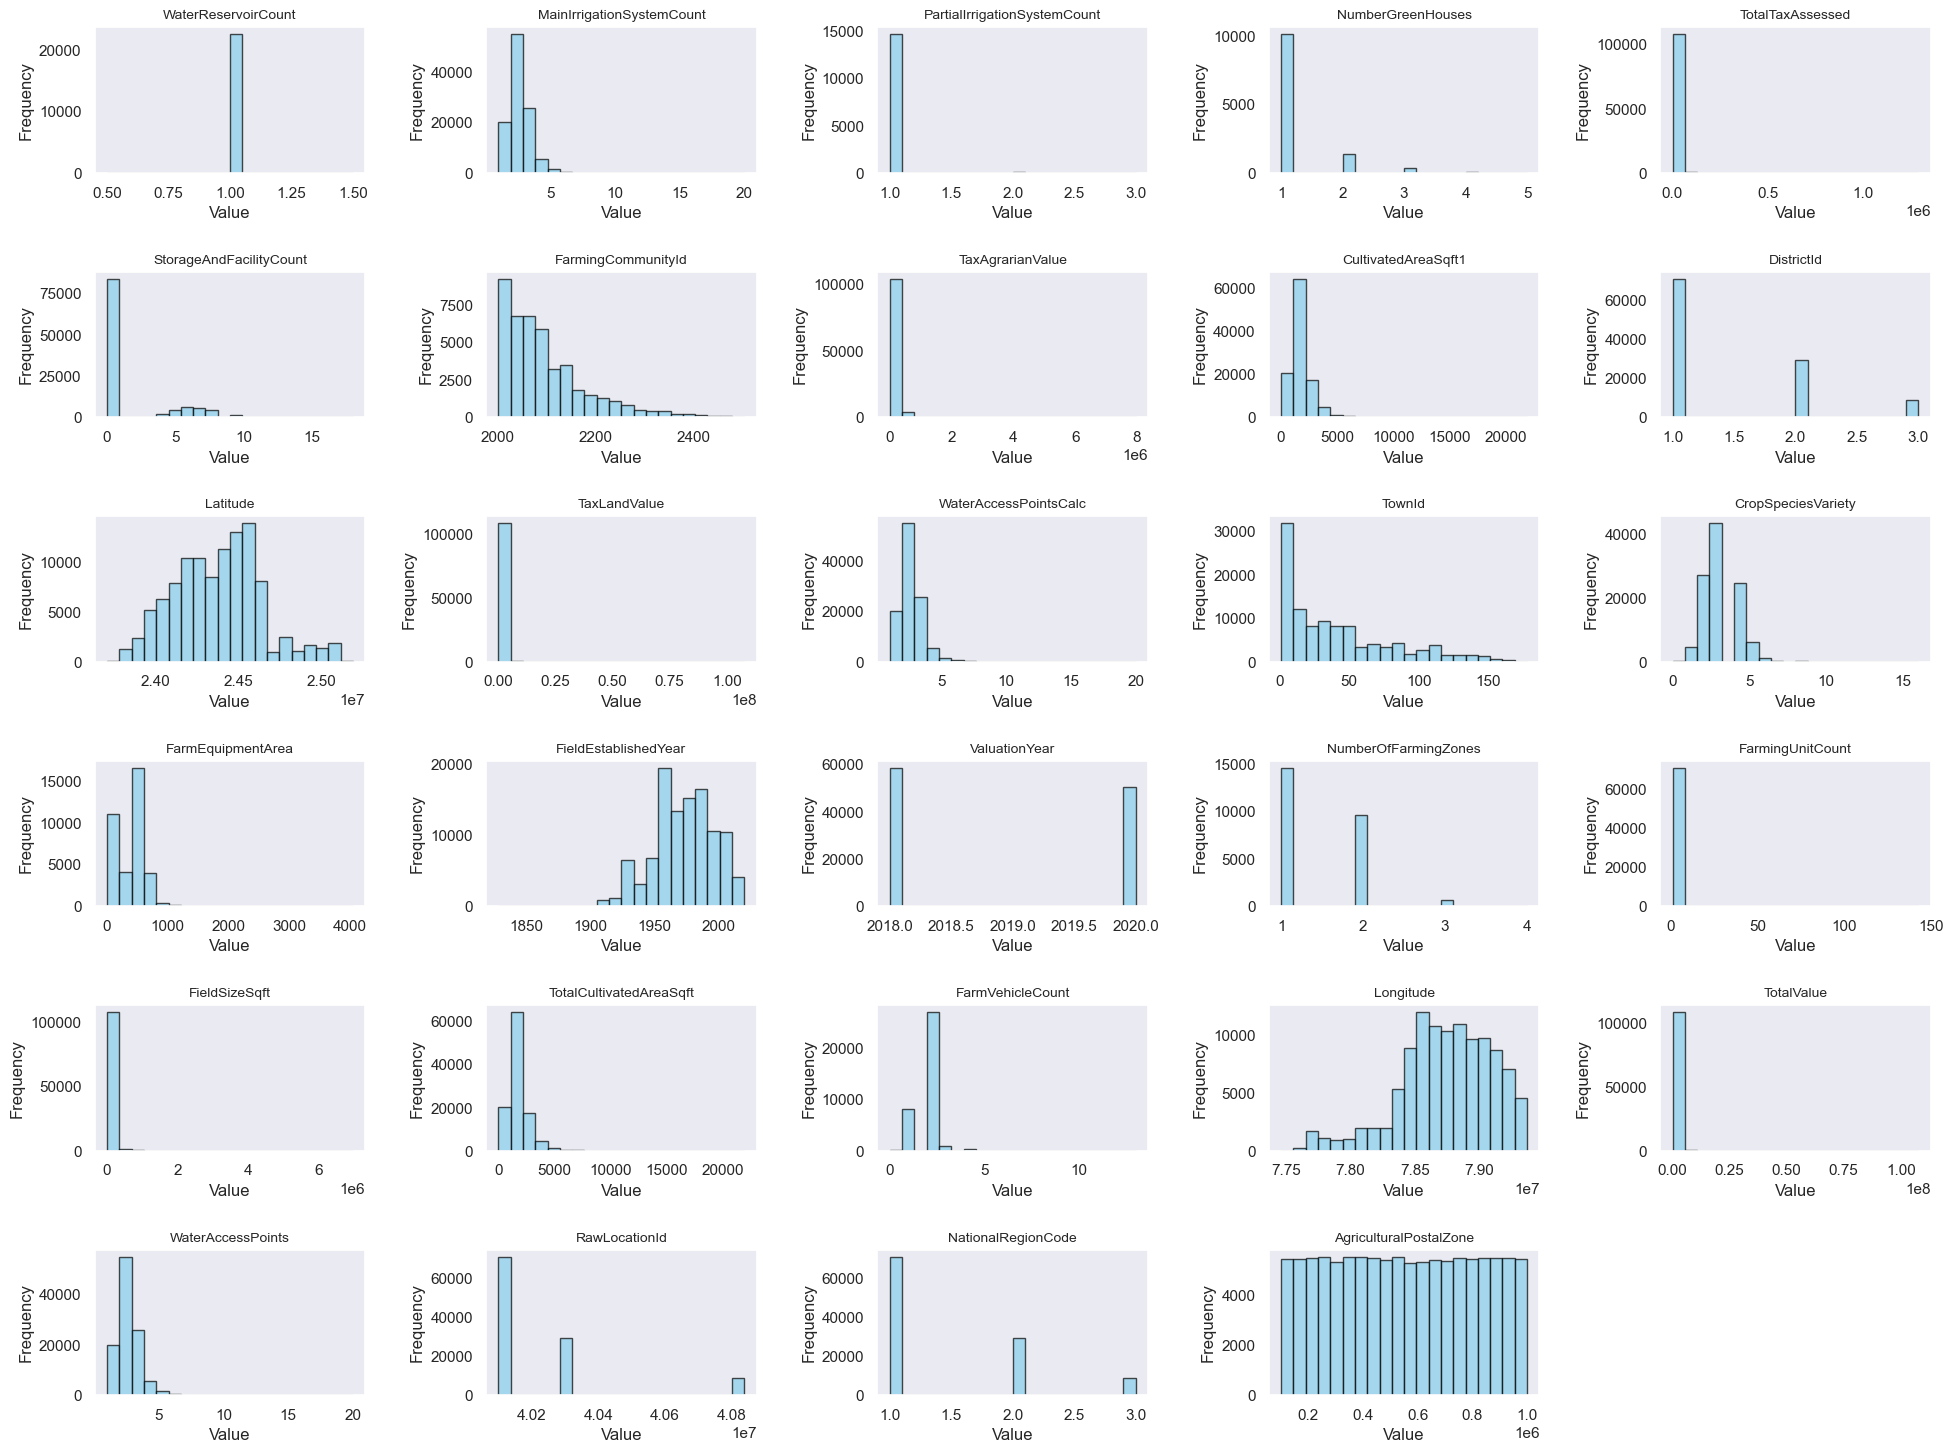

In [22]:
dropped_columns, X_train, y_train, X_test = histogramAnalysis(dropped_columns, X_train, y_train, X_test)

In [23]:
X_train = enhance_features(X_train)
X_test = enhance_features(X_test)


Enhancing Features...

Enhancing Features...


In [24]:
dropped_columns, X_train, y_train, X_test = onehotencoding_and_imputing(dropped_columns, X_train, y_train, X_test)
X_train.shape, X_test.shape

((108985, 103), (15921, 103))

In [25]:
dropped_columns = identify_highly_correlated_columns(
    dropped_columns, X_train[list(X_train.columns.difference(dropped_columns))]
)

X_train_features = X_train[list(X_train.columns.difference(dropped_columns))]
X_test_features = X_test[list(X_train.columns.difference(dropped_columns))]

X_train_features.shape, X_test_features.shape

((108985, 71), (15921, 71))

In [26]:
X_train_selected, X_test_selected = select_features(X_train_features, X_test_features, y_train)
X_train_selected.columns.tolist()

['TotalCultivatedAreaSqft',
 'RawLocationId',
 'TownId',
 'FieldEstablishedYear',
 'TaxBurden',
 'AgricultureZoningCode',
 'FarmVehicleCount',
 'FarmingCommunityId',
 'FieldSizeSqft',
 'IrrigationAreaDensity',
 'OtherZoningCode',
 'FarmEquipmentArea',
 'FieldUtilization',
 'WaterAccessPointsCalc',
 'FarmingUnitCount',
 'NaturalLakePresence',
 'PartialIrrigationSystemCount',
 'SoilFertilityType_7.0',
 'TaxAgrarianValue',
 'NumberGreenHouses',
 'TotalValue',
 'WaterAreaDensity',
 'NumberOfFarmingZones',
 'WaterReservoirCount',
 'WaterResources']

In [27]:
model, y_pred = pca_and_model_training(X_train_selected, X_test_selected, y_train)

In [28]:
target_mapping = {0: 'low', 1: 'medium', 2: 'high'}
y_pred_mapped = pd.Series(y_pred).map(target_mapping)

result_df = pd.DataFrame({
    'UID': X_test['UID'],
    'Target': y_pred_mapped
})

result_df.to_csv(PREDICTIONS_FILE, index=False)
print(f"Saved {len(result_df)} predictions to {PREDICTIONS_FILE}")

Saved 15921 predictions to ../data/predictions.csv


## Results

The generated predictions are reviewed below, including a preview of the output and the
distribution of predicted classes across the test set.

In [29]:
result_df.head()

,UID,Target
0,130000,medium
1,129101,low
2,147876,medium
3,122624,medium
4,159920,medium


In [30]:
result_df['Target'].value_counts()

Target
medium    8734
low       3679
high      3508
Name: count, dtype: int64